# **🚦Saudi Traffic Sign Classification**

### **1 - Environment Setup**
Install all required packages and import libraries needed throughout the project.

**1.1 Install Dependencies**

In [2]:
pip install -r requirements.txt

  Using cached keras_cv-0.9.0-py3-none-any.whl.metadata (12 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 41.5/41.5 kB 1.0 MB/s eta 0:00:00
  Using cached tensorflow_datasets-4.9.9-py3-none-any.whl.metadata (11 kB)
  Using cached keras_core-0.1.7-py3-none-any.whl.metadata (4.3 kB)
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 43.1/43.1 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/108.8 kB ? eta -:--:--
     ------------------------- ------------- 71.7/108.8 kB 1.3 MB/s eta 0:00:01
     ------------------------- ------------- 71.7/108.8 kB 1.3 MB/s eta 0:00:01
     ------------------------------------ 108.8/108.8 kB 788.2 kB/s eta 0:00:00
  Using cached typing_inspection-0.4.2-py3-none-an

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


**1.2 Import Libraries**

In [6]:
from roboflow import Roboflow
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import os
import copy
import random
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import gradio as gr
from PIL import Image

### **2 - Dataset**
Download the Saudi Traffic Sign Dataset from Roboflow. The dataset is pre-processed and augmented, containing 24 traffic sign classes split into train / validation / test sets.

In [ ]:
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("hayas-workspace-vivrw").project("saudi-traffic-sign-dataset")
version = project.version(2)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Saudi-Traffic-Sign-Dataset-2 in folder:: 100%|██████████| 7536/7536 [00:00<00:00, 10329.45it/s]


### **3 - Configuration & Reproducibility**
Define all hyperparameters in one place for easy tuning, and fix random seeds to ensure reproducible results.

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-4
NUM_CLASSES = 24
DATASET_DIR = dataset.location

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

### **4 - Data Preprocessing & DataLoaders**
Apply standard ImageNet normalization transforms and create DataLoaders for train, validation, and test splits.

In [9]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_DIR, "valid"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATASET_DIR, "test"),  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 24
Train: 6055 | Val: 807 | Test: 672


### **5 - Model Definitions**
Build five pretrained transformer models using the `timm` library. All models are initialized with ImageNet weights and their classification heads are replaced with a 'NUM_CLASSES' output layer.

| Model        | Architecture                           |
|:-------------|:---------------------------------------|
| ViT          | `vit_base_patch16_224`                 |
| Swin         | `swin_base_patch4_window7_224`         |
| MobileViT    | `mobilevit_s`                          |
| EfficientViT | `efficientvit_b1`                      |

In [10]:
def build_model(model_name, num_classes):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)

models_to_train = {
    "ViT":    build_model("vit_base_patch16_224", NUM_CLASSES),
    "Swin":  build_model("swin_base_patch4_window7_224", NUM_CLASSES),
    "MobileViT":  build_model("mobilevit_s", NUM_CLASSES),
    "EfficientViT": build_model("efficientvit_b1", NUM_CLASSES)
}

print("All models built:")
for name, model in models_to_train.items():
    params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {name}: {params:.1f}M parameters")


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.5M [00:00<?, ?B/s]

All models built:
  ViT: 85.8M parameters
  Swin: 86.8M parameters
  MobileViT: 5.0M parameters
  EfficientViT: 7.5M parameters


### **6 - Model Training**
Train each model with:
- **Optimizer:** AdamW (weight decay = 1e-4)
- **LR Scheduler:** ReduceLROnPlateau (patience = 3, factor = 0.5)
- **Loss:** CrossEntropyLoss
- **Early Stopping:** patience of 7 epochs with no validation improvement
- **Checkpointing:** Best weights saved to disk after each improvement


In [11]:
def train_model(name, model, train_loader, val_loader, epochs, lr):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_weights = None
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    no_improve = 0

    for epoch in range(epochs):
        # Train phase
        model.train()
        train_loss, train_correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

        train_acc  = train_correct / total
        train_loss = train_loss / total

        # Val phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)

        val_acc  = val_correct / val_total
        val_loss = val_loss / val_total

        scheduler.step(val_loss)

        # Record history
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

        # Save best model and early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f"/content/{name}_best.pth")
            print(f"  ✅ Best model saved ({best_acc*100:.2f}%)")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 7:
                print(f"  ⏹ Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    model.load_state_dict(best_weights)
    return history

# Train all models
histories = {}
for name, model in models_to_train.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    histories[name] = train_model(name, model, train_loader, val_loader, EPOCHS, LEARNING_RATE)
    print(f"Finished: {name}")


Training: ViT
Epoch [1/25] Train Loss: 0.4360 Acc: 86.77% | Val Loss: 0.0396 Acc: 99.01%
  ✅ Best model saved (99.01%)
Epoch [2/25] Train Loss: 0.0662 Acc: 97.90% | Val Loss: 0.1413 Acc: 95.91%
Epoch [3/25] Train Loss: 0.0713 Acc: 98.07% | Val Loss: 0.0535 Acc: 98.39%
Epoch [4/25] Train Loss: 0.0348 Acc: 98.94% | Val Loss: 0.0274 Acc: 99.50%
  ✅ Best model saved (99.50%)
Epoch [5/25] Train Loss: 0.0440 Acc: 98.60% | Val Loss: 0.0222 Acc: 99.38%
Epoch [6/25] Train Loss: 0.0016 Acc: 99.97% | Val Loss: 0.0139 Acc: 99.63%
  ✅ Best model saved (99.63%)
Epoch [7/25] Train Loss: 0.0018 Acc: 99.97% | Val Loss: 0.0319 Acc: 99.13%
Epoch [8/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0292 Acc: 99.26%
Epoch [9/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0279 Acc: 99.38%
Epoch [10/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0271 Acc: 99.38%
Epoch [11/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0268 Acc: 99.38%
Epoch [12/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0265

### **7 - Model Evaluation**
Evaluate each model on the held-out **test set** and generate a full `sklearn` classification report including per-class precision, recall, and F1-score.

In [12]:
def evaluate_model(name, model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    return y_true, y_pred, report

results = {}
for name, model in models_to_train.items():
    print(f"Model: {name}...")
    y_true, y_pred, report = evaluate_model(name, model, test_loader)
    results[name] = {"y_true": y_true, "y_pred": y_pred, "report": report}
    print(f"  Accuracy: {report['accuracy']*100:.2f}%")

Model: ViT...
  Accuracy: 99.26%
Model: Swin...
  Accuracy: 99.55%
Model: MobileViT...
  Accuracy: 99.11%
Model: EfficientViT...
  Accuracy: 99.11%


### **8 - Model Visualization**
Generate and save: summary table, accuracy curves, confusion matrices, and a grouped bar chart.


In [13]:
# Summary table
summary = []
for name, res in results.items():
    r = res["report"]
    summary.append({
        "Model":     name,
        "Accuracy":  round(r["accuracy"] * 100, 2),
        "Precision": round(r["weighted avg"]["precision"] * 100, 2),
        "Recall":    round(r["weighted avg"]["recall"] * 100, 2),
        "F1-Score":  round(r["weighted avg"]["f1-score"] * 100, 2),
    })

df = pd.DataFrame(summary).sort_values("Accuracy", ascending=False)
print("\n📊 Model Comparison on Test Set:")
print(df.to_string(index=False))
df.to_csv("/content/model_comparison.csv", index=False)


📊 Model Comparison on Test Set:
       Model  Accuracy  Precision  Recall  F1-Score
        Swin     99.55      99.57   99.55     99.55
         ViT     99.26      99.31   99.26     99.25
   MobileViT     99.11      99.16   99.11     99.11
EfficientViT     99.11      99.16   99.11     99.11


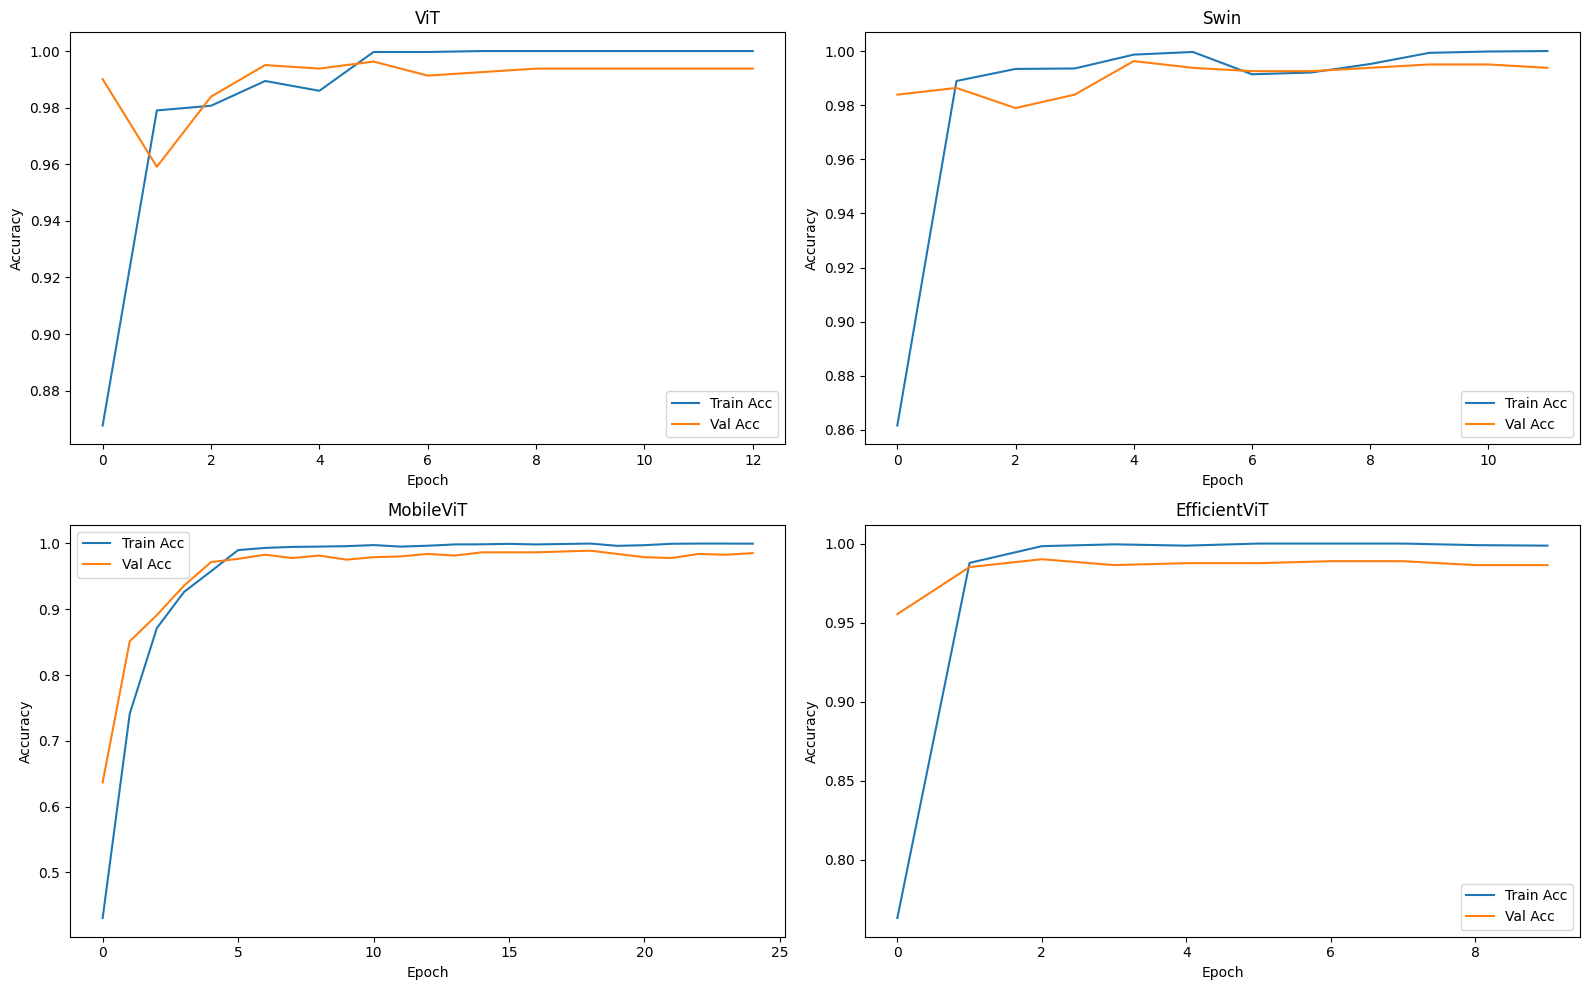

In [14]:
# Accuracy curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, (name, hist) in enumerate(histories.items()):
    axes[i].plot(hist["train_acc"], label="Train Acc")
    axes[i].plot(hist["val_acc"],   label="Val Acc")
    axes[i].set_title(f"{name}")
    axes[i].legend()
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig("/content/accuracy_curves.png", dpi=150)
plt.show()

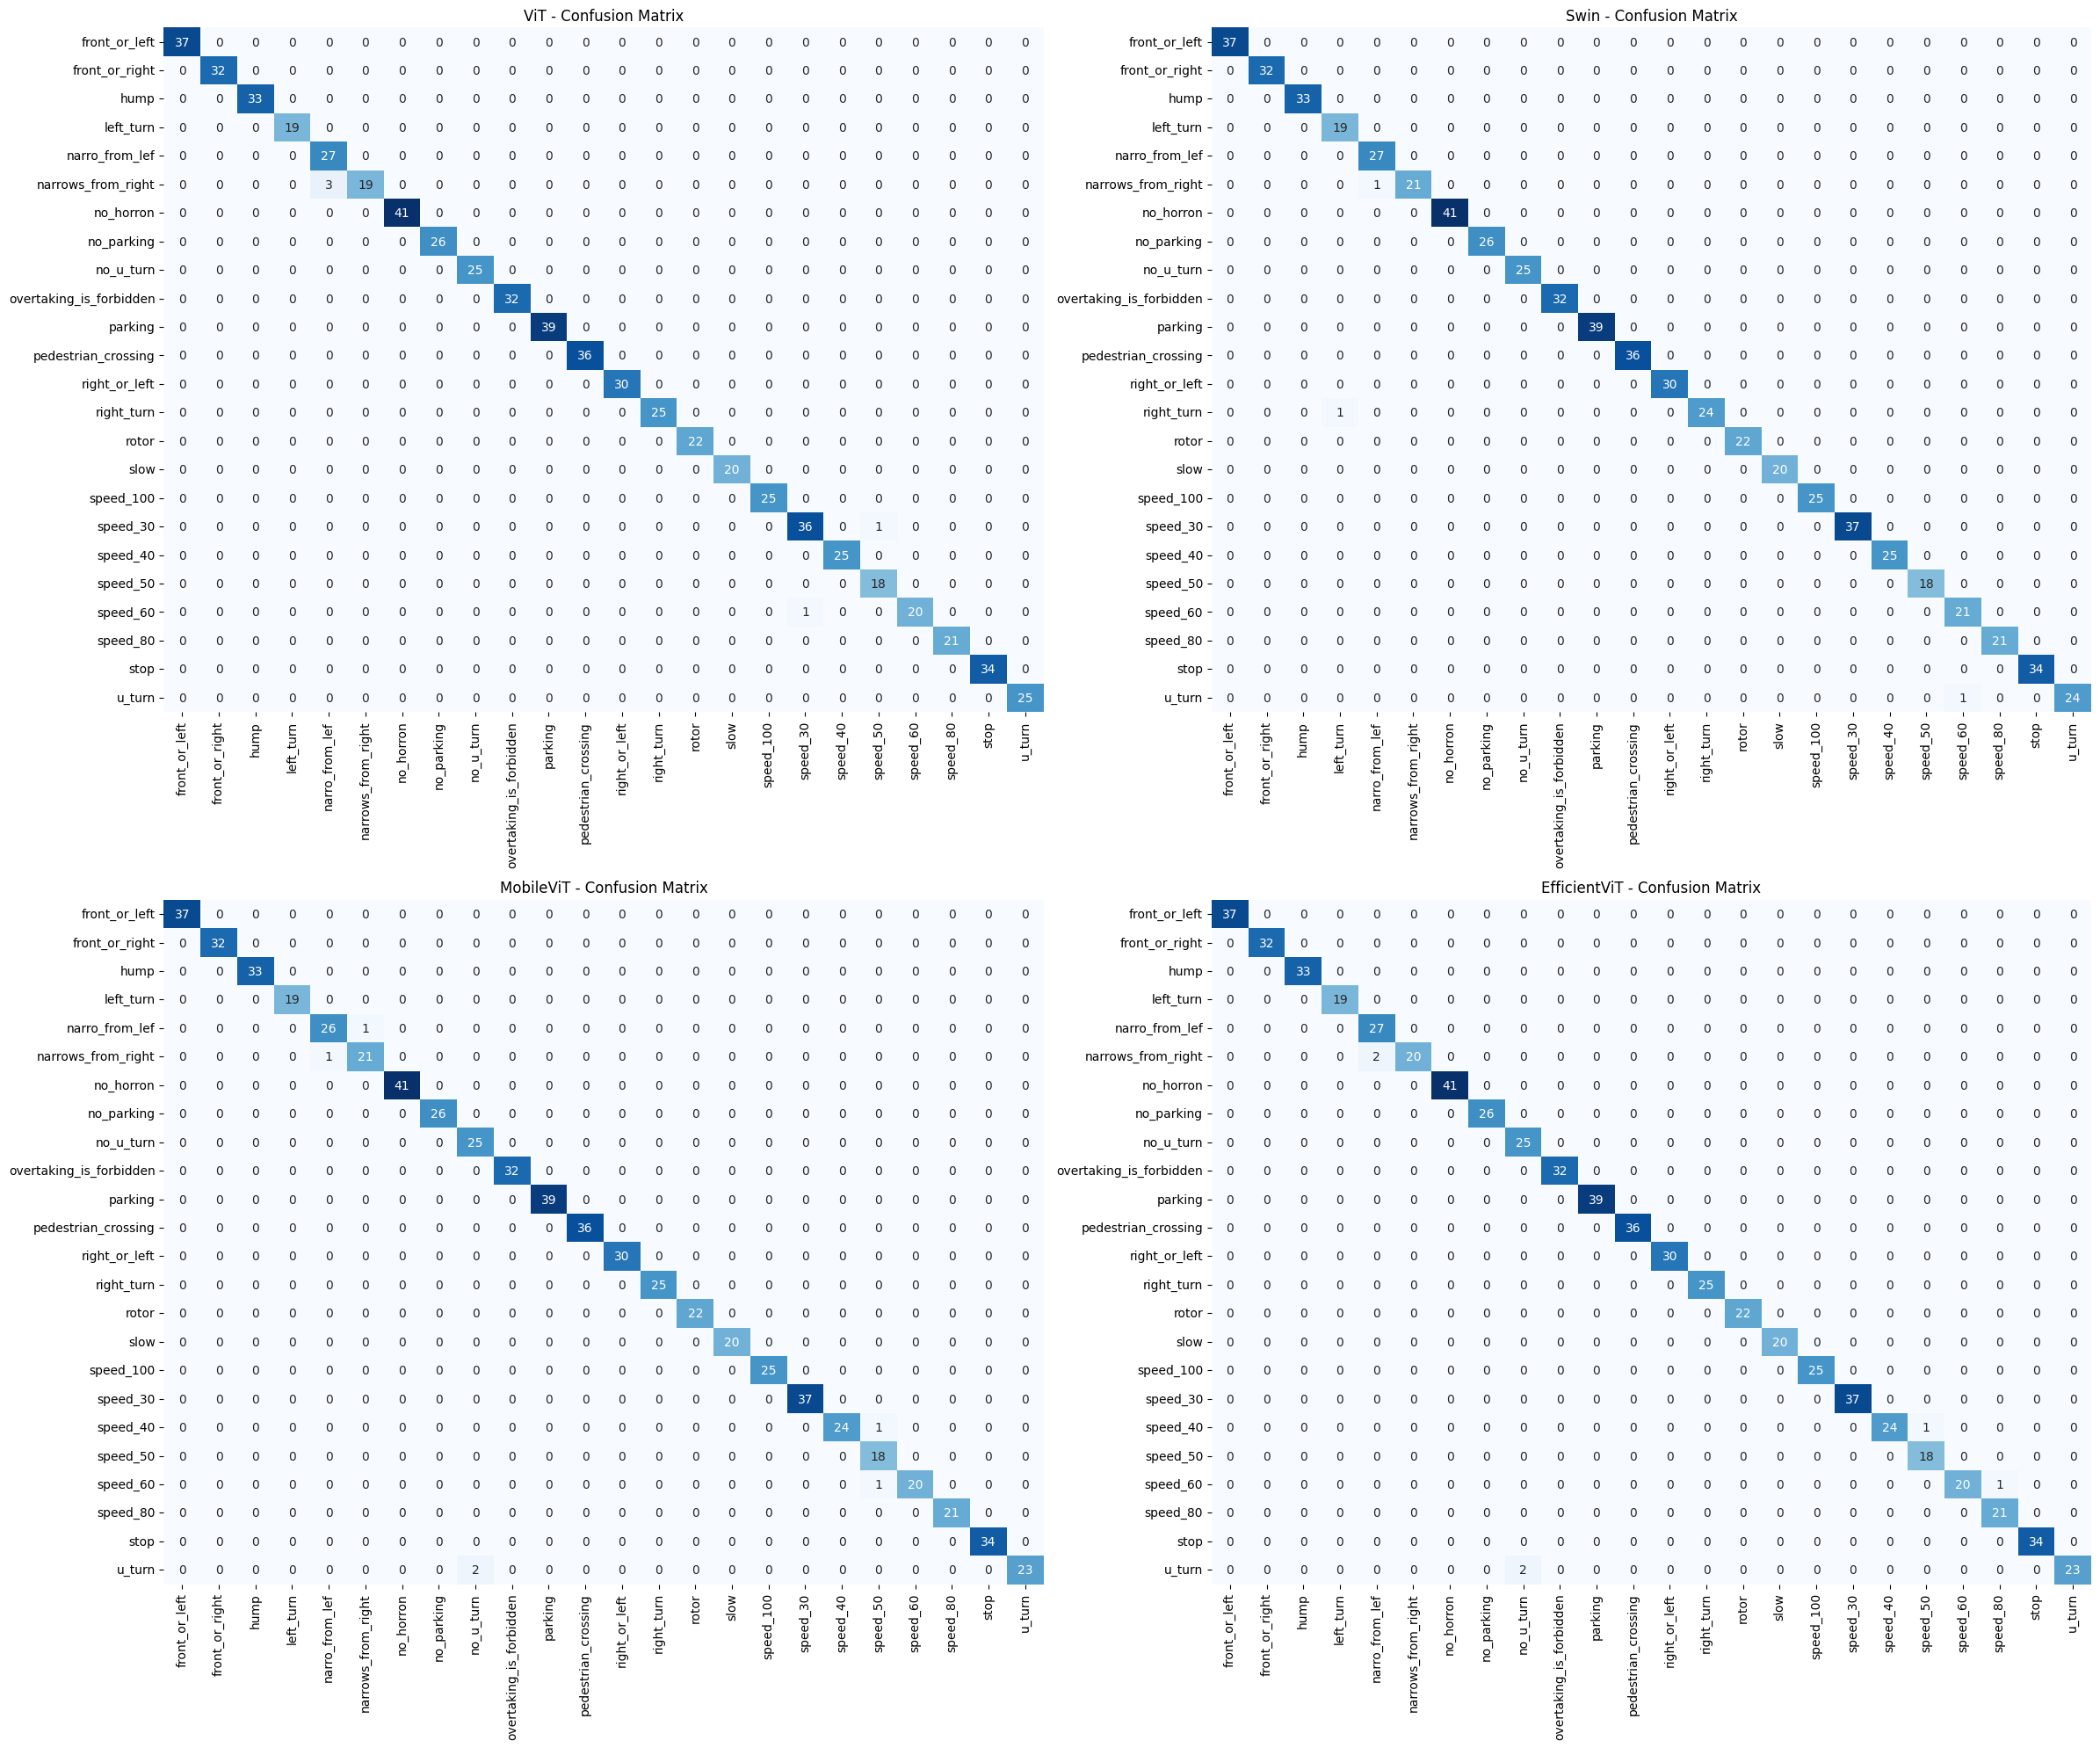

In [15]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i],
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                cmap="Blues", cbar=False)
    axes[i].set_title(f"{name} - Confusion Matrix")
    axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=150)
plt.show()

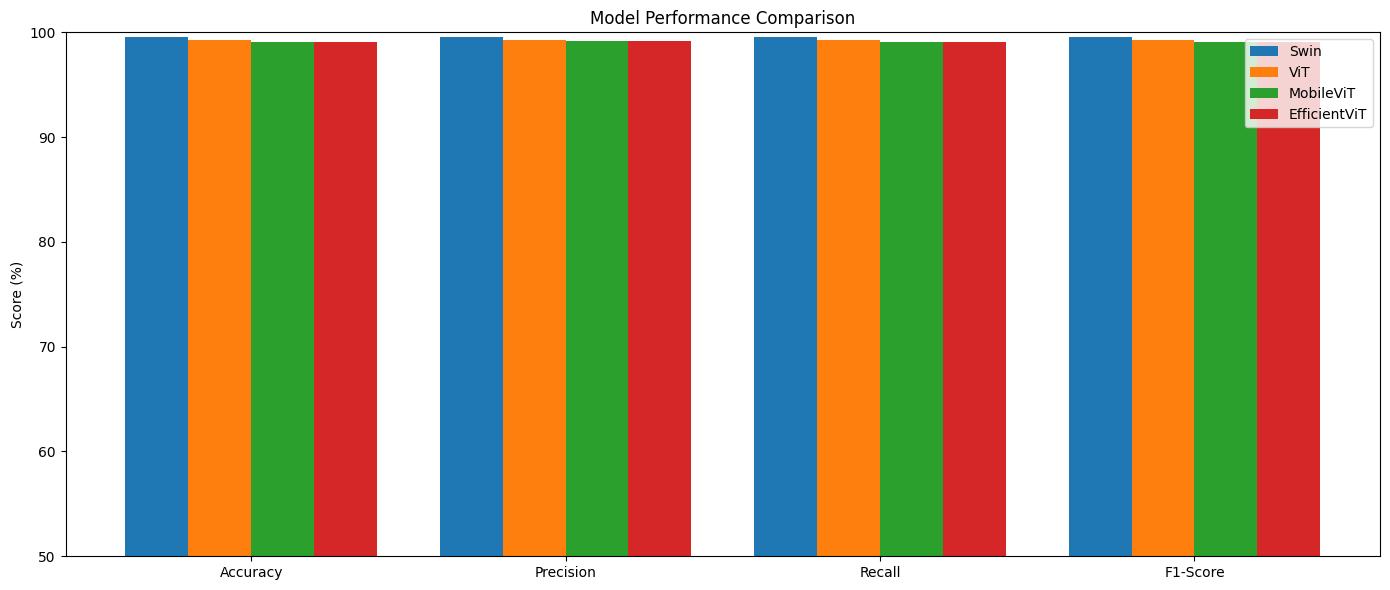

In [16]:
# Bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row["Model"])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score (%)")
ax.set_title("Model Performance Comparison")
ax.legend()
ax.set_ylim(50, 100)
plt.tight_layout()
plt.savefig("/content/model_bar_comparison.png", dpi=150)
plt.show()

### **9 - Gradio UI**
Launch an interactive web UI with four tabs:
- **Single Model** — Detailed confidence scores and bar chart for one model
- **Compare All Models** — Side-by-side predictions from all five models
- **Model Info** — Parameter counts and class label reference
- **Performance Results** — Test-set metrics table


In [18]:
def predict(image, model_name, top_k=5):
    if image is None:
        return None, None

    # Select model
    model = models_to_train[model_name]
    model.eval()

    # Preprocess image
    img_tensor = transform(image).unsqueeze(0).to(DEVICE)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)[0]

    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, top_k)
    top_probs   = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()

    top_classes = [CLASS_NAMES[i] for i in top_indices]

    # Build confidence dict for gradio label
    confidences = {cls: float(prob)
                   for cls, prob in zip(top_classes, top_probs)}

    # Build bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#2ecc71" if i == 0 else "#3498db"
              for i in range(len(top_classes))]
    bars = ax.barh(top_classes[::-1], top_probs[::-1] * 100, color=colors[::-1])
    ax.set_xlabel("Confidence (%)")
    ax.set_title(f"Top {top_k} Predictions — {model_name}")
    ax.set_xlim(0, 100)

    # Add value labels on bars
    for bar, prob in zip(bars, top_probs[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{prob*100:.1f}%", va="center", fontsize=10)

    plt.tight_layout()

    return confidences, fig

def predict_all_models(image):
    """Run all models and return combined comparison"""
    if image is None:
        return [None] * len(models_to_train)

    results = []
    for name, model in models_to_train.items():
        model.eval()
        img_tensor = transform(image).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)[0]

        top_probs, top_indices = torch.topk(probs, 3)
        top_probs   = top_probs.cpu().numpy()
        top_indices = top_indices.cpu().numpy()
        top_classes = [CLASS_NAMES[i] for i in top_indices]

        result = f"**{name}**\n"
        for cls, prob in zip(top_classes, top_probs):
            bar = "█" * int(prob * 20)
            result += f"  {cls}: {prob*100:.1f}% {bar}\n"
        results.append(result)

    return results


# Build Gradio UI
with gr.Blocks(theme=gr.themes.Soft(), title="Saudi Traffic Sign Classifier") as demo:

    gr.Markdown("""
    # 🚦 Saudi Traffic Sign Classifier
    ### Compare ViT, Swin, MobileViT, and EfficientViT
    Upload a traffic sign image to classify it using multiple transformer models.""")

    with gr.Tabs():

        # Tab 1: Single Model
        with gr.Tab("🔍 Single Model"):
            gr.Markdown("Test one model at a time with detailed confidence scores.")

            with gr.Row():
                with gr.Column(scale=1):
                    img_input = gr.Image(type="pil", label="Upload Traffic Sign")
                    model_dropdown = gr.Dropdown(
                        choices=list(models_to_train.keys()),
                        value=list(models_to_train.keys())[0],
                        label="Select Model"
                    )
                    top_k_slider = gr.Slider(
                        minimum=3, maximum=10, value=5, step=1,
                        label="Top-K Predictions"
                    )
                    predict_btn = gr.Button("Predict", variant="primary")

                with gr.Column(scale=2):
                    label_output = gr.Label(label="Predictions")
                    chart_output = gr.Plot(label="Confidence Chart")

            predict_btn.click(
                fn=predict,
                inputs=[img_input, model_dropdown, top_k_slider],
                outputs=[label_output, chart_output]
            )

        # Tab 2: Compare All Models
        with gr.Tab("⚡ Compare All Models"):
            gr.Markdown("Upload one image and compare predictions from all models simultaneously.")

            with gr.Row():
                with gr.Column(scale=1):
                    img_compare = gr.Image(type="pil", label="Upload Traffic Sign")
                    compare_btn = gr.Button("🔄 Compare All Models", variant="primary")

                with gr.Column(scale=2):
                    gr.Markdown("### Results")
                    model_outputs = [
                        gr.Markdown(label=name)
                        for name in models_to_train.keys()
                    ]

            compare_btn.click(
                fn=predict_all_models,
                inputs=[img_compare],
                outputs=model_outputs
            )

        # Tab 3: Model Info
        with gr.Tab("📊 Model Info"):
            gr.Markdown("### Model Summary")

            info_data = []
            for name, model in models_to_train.items():
                params = sum(p.numel() for p in model.parameters()) / 1e6
                trainable = sum(p.numel() for p in model.parameters()
                                if p.requires_grad) / 1e6
                info_data.append([name, f"{params:.1f}M", f"{trainable:.1f}M"])

            gr.Dataframe(
                value=info_data,
                headers=["Model", "Total Params", "Trainable Params"],
                label="Model Parameters"
            )

            gr.Markdown("### Class Labels")
            gr.Dataframe(
                value=[[i, cls] for i, cls in enumerate(CLASS_NAMES)],
                headers=["ID", "Class Name"],
                label="Saudi Traffic Sign Classes"
            )

        # Tab 4: Performance Results
        with gr.Tab("🏆 Performance Results"):
            gr.Markdown("### Test Set Performance")

            # Show results table if evaluation already done
            try:
                perf_data = []
                for name, res in results.items():
                    r = res["report"]
                    perf_data.append([
                        name,
                        f"{r['accuracy']*100:.2f}%",
                        f"{r['weighted avg']['precision']*100:.2f}%",
                        f"{r['weighted avg']['recall']*100:.2f}%",
                        f"{r['weighted avg']['f1-score']*100:.2f}%",
                    ])
                gr.Dataframe(
                    value=perf_data,
                    headers=["Model", "Accuracy", "Precision", "Recall", "F1-Score"],
                    label="Performance Comparison"
                )
            except:
                gr.Markdown("Run the evaluation step first to see results here.")

# Launch
demo.launch(share=True, debug=True)

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://be241b36092c856dd9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://be241b36092c856dd9.gradio.live
